In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Input
from tensorflow.keras.models import Model

In [2]:
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
noise_factor = 0.3

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_train.shape)

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=X_test.shape)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

In [4]:
input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

In [5]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [6]:
history = autoencoder.fit(
    X_train_noisy, X_train,
    epochs=5,
    batch_size=128,
    validation_data=(X_test_noisy, X_test)
)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 169s 356ms/step - loss: 0.1288 - val_loss: 0.0890
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 171s 364ms/step - loss: 0.0871 - val_loss: 0.0844
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 352ms/step - loss: 0.0836 - val_loss: 0.0826
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 170s 362ms/step - loss: 0.0819 - val_loss: 0.0804
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 171s 364ms/step - loss: 0.0807 - val_loss: 0.0797


In [7]:
denoised = autoencoder.predict(X_test_noisy[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


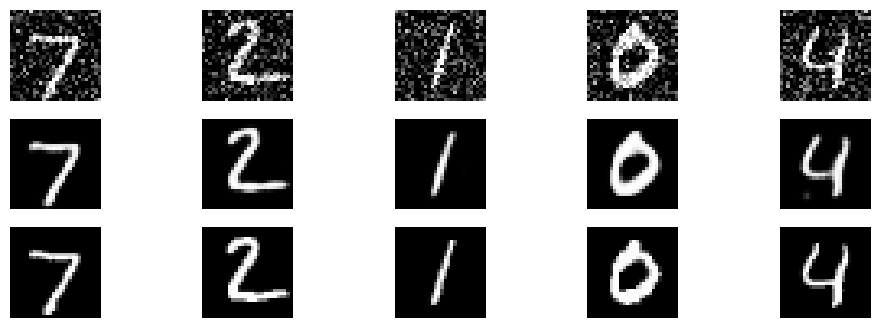

In [8]:
plt.figure(figsize=(12,4))

for i in range(5):

    # Noisy
    ax = plt.subplot(3,5,i+1)
    plt.imshow(X_test_noisy[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3,5,i+6)
    plt.imshow(denoised[i].reshape(28,28), cmap='gray')
    plt.axis("off")

    # Original
    ax = plt.subplot(3,5,i+11)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()